# Amazon Review Sentiment Analysis — 01 Exploratory Data Analysis

A **text-classification** project that classifies Amazon product reviews as positive or negative sentiment. **Binary** classification — positive vs negative.

We use a TF-IDF + classic-ML pipeline: this notebook explores the raw text and labels.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
%matplotlib inline
import utils

df=utils.load_data()
print('rows:',len(df),'| classes:',df['label'].nunique())
df.head(3)

rows: 30000 | classes: 2


,text,label
0,"It all sounds the same, but.... It's all good....",positive
1,"Sedaris can be more than merely ""funny"". I fou...",positive
2,good book. i have not had alot of time to chec...,positive


## 1. Class distribution

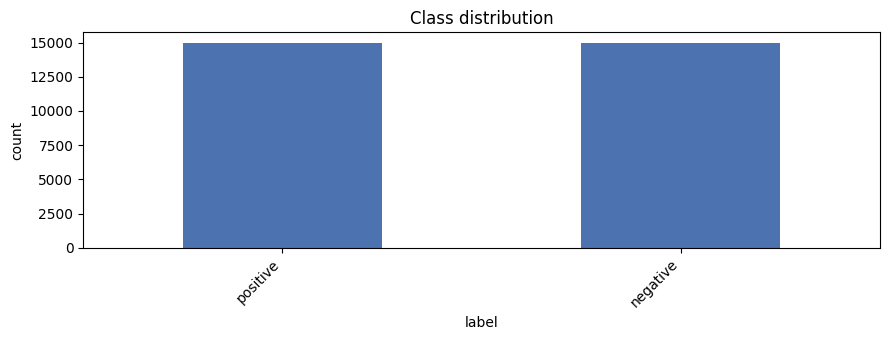

label
positive    15000
negative    15000


In [2]:
fig,ax=plt.subplots(figsize=(9,3.5))
vc=df['label'].value_counts()
vc.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Class distribution'); ax.set_ylabel('count')
plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 2. Text length distribution

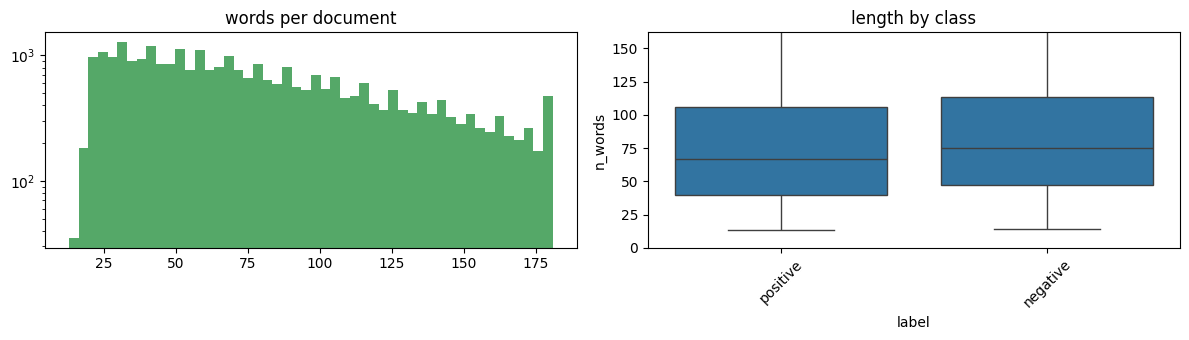

words per doc — median 71, max 212


In [3]:
df['n_words']=df['text'].astype(str).str.split().apply(len)
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['n_words'].clip(upper=df['n_words'].quantile(0.99)),bins=50,color='#55a868'); ax[0].set_title('words per document'); ax[0].set_yscale('log')
sns.boxplot(x='label',y='n_words',data=df,ax=ax[1]); ax[1].set_ylim(0,df['n_words'].quantile(0.95)); ax[1].set_title('length by class'); ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()
print('words per doc — median %d, max %d'%(df['n_words'].median(),df['n_words'].max()))

## 3. Most frequent words (raw)

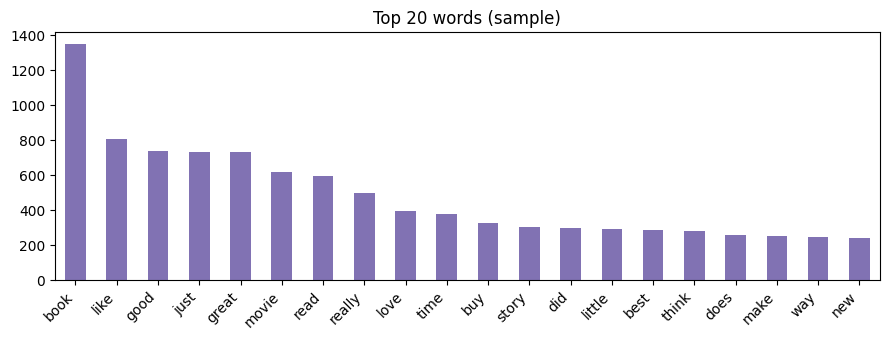

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
words=Counter()
for t in df['text'].astype(str).head(3000):
    words.update(w for w in t.lower().split() if w.isalpha() and w not in ENGLISH_STOP_WORDS and len(w)>2)
top=pd.Series(dict(words.most_common(20)))
fig,ax=plt.subplots(figsize=(9,3.5)); top.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Top 20 words (sample)'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 4. Sample documents per class

In [5]:
for lab in df['label'].unique()[:6]:
    s=df[df['label']==lab]['text'].iloc[0]
    print(f'[{lab}] '+str(s)[:160].replace(chr(10),' ')+'...\n')

[positive] It all sounds the same, but.... It's all good. This album suffers from a common problem among metal albums in that almost all the songs sound very similar, but ...

[negative] NOT FOR KIDS!. I got this movie for my 6 and 5 year old sons who love transformers! We have watched other PG rated movies before like Shrek...I was appalled to ...



## 5. Summary

The raw text and class balance above motivate the cleaning (notebook 02) and the TF-IDF + classic-ML modelling (notebook 03). Text length and vocabulary vary by class, which is exactly the signal the classifiers will exploit.